# 07. Signal Preprocessing Validation

## Objective

This notebook documents and validates the final preprocessing pipeline applied to the PADS smartwatch movement recordings before wearable feature extraction.

The preprocessing stage transforms the raw accelerometer and gyroscope recordings into a consistent representation while preserving the original task-specific movement information.

The final pipeline includes:

1. L1 trend filtering of the three accelerometer axes using `λ = 50`.
2. CLARABEL as the numerical solver for all recordings.
3. Removal of the first 48 samples associated with the initial smartwatch notification vibration.
4. Re-zeroing of the time channel after trimming.
5. Preservation of the original gyroscope signals.
6. Calculation of accelerometer and gyroscope vector magnitudes.
7. Storage of the processed signals in one compressed `.npz` file per participant.

The notebook evaluates:

- dataset-wide preprocessing outcomes,
- numerical solver status,
- task- and wrist-level patterns,
- processing time,
- participant-level `.npz` structure,
- recording lengths,
- raw versus processed signals,
- signal magnitude calculations,
- and final dataset integrity.

The processed wearable signals will subsequently be used for time-domain, frequency-domain, task-specific, wrist-specific, and symmetry feature engineering.

## Methodological Approach

The original PADS preprocessing implementation was used as a methodological reference.

The original L1 trend-filter formulation and regularization parameter (`λ = 50`) were retained for accelerometer preprocessing. However, the original CVXOPT solver was computationally expensive for dataset-wide processing.

Alternative numerical solvers were therefore evaluated while preserving the same optimization problem. CLARABEL was selected for the final pipeline because it provided substantially faster processing while producing highly similar filtered signals during solver comparison.

The same CLARABEL configuration was subsequently applied to every recording in the dataset to ensure preprocessing consistency.

Both `optimal` and `optimal_inaccurate` solver outcomes were retained. The latter represents a reduced-accuracy numerical solution rather than a preprocessing failure and is explicitly recorded in the quality report for auditing.

Unlike the original author-provided machine-learning preprocessing workflow, this project preserves all 11 motor tasks because task-specific movement characteristics are required for the planned wearable feature analysis.

In [1]:
# Libraries and project paths
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
# Detect project root
cwd = Path.cwd()
if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the data/ directory."
    )

RAW_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "movement"
    / "timeseries"
)
PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)
NPZ_DIR = (
    PROCESSED_DIR
    / "preprocessed_signals"
)
REPORT_PATH = (
    PROCESSED_DIR
    / "preprocessing_report.csv"
)

print("Project root:", PROJECT_ROOT)
print("Raw signals:", RAW_DIR)
print("Processed signals:", NPZ_DIR)
print("Preprocessing report:", REPORT_PATH)

Project root: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease
Raw signals: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\data\raw\movement\timeseries
Processed signals: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed\preprocessed_signals
Preprocessing report: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed\preprocessing_report.csv


## 1. Load the Dataset-Wide Preprocessing Report

The dataset-wide preprocessing pipeline generated one quality-control record for each smartwatch recording.

Each report row represents one unique:

**participant × motor task × wrist**

combination.

The report contains information about:

- raw and processed sample counts,
- L1 trend-filter configuration,
- solver status for each accelerometer axis,
- solver iterations and processing time,
- numerical warnings,
- final recording status,
- and participant `.npz` creation.

In [2]:
# Load preprocessing report
# =============================================================================
report = pd.read_csv( REPORT_PATH, dtype={"patient_id": str},)
print("Report shape:", report.shape)
report.head()

Report shape: (10318, 31)


,patient_id,task,wrist,input_file,npz_key,raw_samples,processed_samples,samples_removed,l1_lambda,solver,processing_time_seconds,acc_x_status,acc_y_status,acc_z_status,acc_x_solver_time_seconds,acc_y_solver_time_seconds,acc_z_solver_time_seconds,acc_x_iterations,acc_y_iterations,acc_z_iterations,acc_x_warning_count,acc_y_warning_count,acc_z_warning_count,solver_warning_count,acc_x_warnings,acc_y_warnings,acc_z_warnings,has_optimal_inaccurate,status,participant_npz_saved,error
0,001,CrossArms,LeftWrist,001_CrossArms_LeftWrist.txt,CrossArms__LeftWrist,1024,976,48,50.0,CLARABEL,0.3395,optimal,optimal,optimal,0.046424,0.042930,0.061873,16,15,17,0,0,0,0,NaN,NaN,NaN,False,PASSED_OPTIMAL,True,NaN
1,001,CrossArms,RightWrist,001_CrossArms_RightWrist.txt,CrossArms__RightWrist,1024,976,48,50.0,CLARABEL,0.3260,optimal,optimal,optimal,0.047658,0.049572,0.049656,15,17,17,0,0,0,0,NaN,NaN,NaN,False,PASSED_OPTIMAL,True,NaN
2,001,DrinkGlas,LeftWrist,001_DrinkGlas_LeftWrist.txt,DrinkGlas__LeftWrist,1024,976,48,50.0,CLARABEL,0.3018,optimal,optimal,optimal,0.037318,0.046653,0.040620,13,16,15,0,0,0,0,NaN,NaN,NaN,False,PASSED_OPTIMAL,True,NaN
3,001,DrinkGlas,RightWrist,001_DrinkGlas_RightWrist.txt,DrinkGlas__RightWrist,1024,976,48,50.0,CLARABEL,0.3038,optimal,optimal,optimal,0.047908,0.048464,0.047066,18,18,16,0,0,0,0,NaN,NaN,NaN,False,PASSED_OPTIMAL,True,NaN
4,001,Entrainment,LeftWrist,001_Entrainment_LeftWrist.txt,Entrainment__LeftWrist,2048,2000,48,50.0,CLARABEL,0.4397,optimal,optimal,optimal,0.081986,0.089131,0.079861,14,16,14,0,0,0,0,NaN,NaN,NaN,False,PASSED_OPTIMAL,True,NaN


In [3]:
# Report structure
# =============================================================================

required_columns = [
    "patient_id",
    "task",
    "wrist",
    "input_file",
    "npz_key",
    "raw_samples",
    "processed_samples",
    "samples_removed",
    "l1_lambda",
    "solver",
    "processing_time_seconds",
    "acc_x_status",
    "acc_y_status",
    "acc_z_status",
    "solver_warning_count",
    "has_optimal_inaccurate",
    "status",
    "participant_npz_saved",
    "error",
]

missing_columns = [
    column
    for column in required_columns
    if column not in report.columns
]

print("Columns in report:", len(report.columns))
print("Required columns missing:", missing_columns)
assert not missing_columns

Columns in report: 31
Required columns missing: []


## 2. Dataset Overview

The expected wearable dataset contains:

- 469 participants,
- 11 standardized motor tasks,
- two wrist locations,
- 22 recordings per participant,
- and 10,318 individual smartwatch recordings.

The following summary verifies that the processed dataset retains this complete structure.

In [4]:
# Dataset overview
# =============================================================================
npz_files = sorted(
    NPZ_DIR.glob("*_preprocessed.npz")
)

overview = pd.DataFrame(
    {
        "Metric": [
            "Participants",
            "Motor tasks",
            "Wrists",
            "Recordings",
            "Participant NPZ files",
        ],
        "Value": [
            report["patient_id"].nunique(),
            report["task"].nunique(),
            report["wrist"].nunique(),
            len(report),
            len(npz_files),
        ],
    }
)
overview

,Metric,Value
0,Participants,469
1,Motor tasks,11
2,Wrists,2
3,Recordings,10318
4,Participant NPZ files,469


In [5]:
# Task and wrist availability
# =============================================================================
print("Motor tasks:")
print(sorted(report["task"].unique()))
print("\nWrists:")
print(sorted(report["wrist"].unique()))

Motor tasks:
['CrossArms', 'DrinkGlas', 'Entrainment', 'HoldWeight', 'LiftHold', 'PointFinger', 'Relaxed', 'RelaxedTask', 'StretchHold', 'TouchIndex', 'TouchNose']

Wrists:
['LeftWrist', 'RightWrist']


## 3. Final Preprocessing Status

Each recording contains three independent L1 trend-filter optimizations corresponding to the X, Y, and Z accelerometer axes.

The final recording status is defined as:

- **PASSED_OPTIMAL**: all three accelerometer axes returned `optimal`.
- **PASSED_INACCURATE**: at least one accelerometer axis returned `optimal_inaccurate`, while a valid processed signal was still produced.
- **FAILED**: preprocessing could not produce a valid recording.

Reduced-accuracy outcomes are retained as a numerical quality indicator rather than automatically excluded from the dataset.

In [6]:
# Recording-level preprocessing status
# =============================================================================

status_summary = (report["status"].value_counts().rename_axis("Status").reset_index(name="Recordings"))

status_summary["Percentage"] = (status_summary["Recordings"]/ len(report)* 100).round(2)
status_summary

,Status,Recordings,Percentage
0,PASSED_OPTIMAL,8841,85.69
1,PASSED_INACCURATE,1477,14.31


In [7]:
# True failures
# =============================================================================

failed_recordings = report[report["status"] == "FAILED"]

print("True preprocessing failures:", len(failed_recordings))

if not failed_recordings.empty:
    display(
        failed_recordings[
            [
                "patient_id",
                "task",
                "wrist",
                "input_file",
                "error",
            ]
        ]
    )

True preprocessing failures: 0


### Overall Result

The complete wearable dataset was successfully processed.

A total of **10,318 recordings from 469 participants** were retained:

- **8,841 recordings (85.69%)** achieved fully optimal solver status across all three accelerometer axes.
- **1,477 recordings (14.31%)** contained at least one reduced-accuracy (`optimal_inaccurate`) accelerometer axis.
- **No true preprocessing failures occurred.**

All recordings were therefore available for subsequent wearable feature engineering.

### Overall Result

The complete wearable dataset was successfully processed.

A total of **10,318 recordings from 469 participants** were retained:

- **8,841 recordings (85.69%)** achieved fully optimal solver status across all three accelerometer axes.
- **1,477 recordings (14.31%)** contained at least one reduced-accuracy (`optimal_inaccurate`) accelerometer axis.
- **No true preprocessing failures occurred.**

All recordings were therefore available for subsequent wearable feature engineering.

In [8]:
# Accelerometer axis solver outcomes
# =============================================================================
axis_status_summary = pd.DataFrame(
    {
        "Accelerometer X": report["acc_x_status"].value_counts(),
        "Accelerometer Y": report["acc_y_status"].value_counts(),
        "Accelerometer Z": report["acc_z_status"].value_counts(),
    }
).fillna(0).astype(int)
axis_status_summary

,Accelerometer X,Accelerometer Y,Accelerometer Z
optimal,9549,9587,9508
optimal_inaccurate,769,731,810


In [9]:
# Axis solver outcome percentages
# =============================================================================

axis_status_pct = (axis_status_summary/ len(report) * 100 ).round(2)

axis_status_pct

,Accelerometer X,Accelerometer Y,Accelerometer Z
optimal,92.55,92.92,92.15
optimal_inaccurate,7.45,7.08,7.85


## 5. Solver Status by Motor Task

The preliminary preprocessing validation suggested that reduced-accuracy numerical solutions were more common during low-movement recordings.

The complete dataset can now be used to determine whether solver behavior is systematically associated with specific motor tasks.

In [10]:
# Recording status by motor task
# =============================================================================
task_status = pd.crosstab(
    report["task"],
    report["status"],
)
task_status

status,PASSED_INACCURATE,PASSED_OPTIMAL
task,,
CrossArms,12,926
DrinkGlas,1,937
Entrainment,22,916
HoldWeight,53,885
LiftHold,0,938
PointFinger,0,938
Relaxed,692,246
RelaxedTask,628,310
StretchHold,69,869


In [11]:
# Percentage status within each task
# =============================================================================
task_status_pct = (
    pd.crosstab(
        report["task"],
        report["status"],
        normalize="index",
    )
    * 100
).round(2)
task_status_pct

status,PASSED_INACCURATE,PASSED_OPTIMAL
task,,
CrossArms,1.28,98.72
DrinkGlas,0.11,99.89
Entrainment,2.35,97.65
HoldWeight,5.65,94.35
LiftHold,0.00,100.00
PointFinger,0.00,100.00
Relaxed,73.77,26.23
RelaxedTask,66.95,33.05
StretchHold,7.36,92.64


In [12]:
# Task-level reduced-accuracy summary
# =============================================================================

task_solver_summary = (
    report
    .groupby("task")
    .agg(
        Total_Recordings=("status", "size"),
        Reduced_Accuracy=(
            "has_optimal_inaccurate",
            "sum",
        ),
    )
)

task_solver_summary[
    "Reduced_Accuracy_Percentage"
] = (
    task_solver_summary["Reduced_Accuracy"]
    / task_solver_summary["Total_Recordings"]
    * 100
).round(2)

task_solver_summary = (
    task_solver_summary
    .sort_values(
        "Reduced_Accuracy_Percentage",
        ascending=False,
    )
)

task_solver_summary

,Total_Recordings,Reduced_Accuracy,Reduced_Accuracy_Percentage
task,,,
Relaxed,938,692,73.77
RelaxedTask,938,628,66.95
StretchHold,938,69,7.36
HoldWeight,938,53,5.65
Entrainment,938,22,2.35
CrossArms,938,12,1.28
DrinkGlas,938,1,0.11
PointFinger,938,0,0.00
LiftHold,938,0,0.00


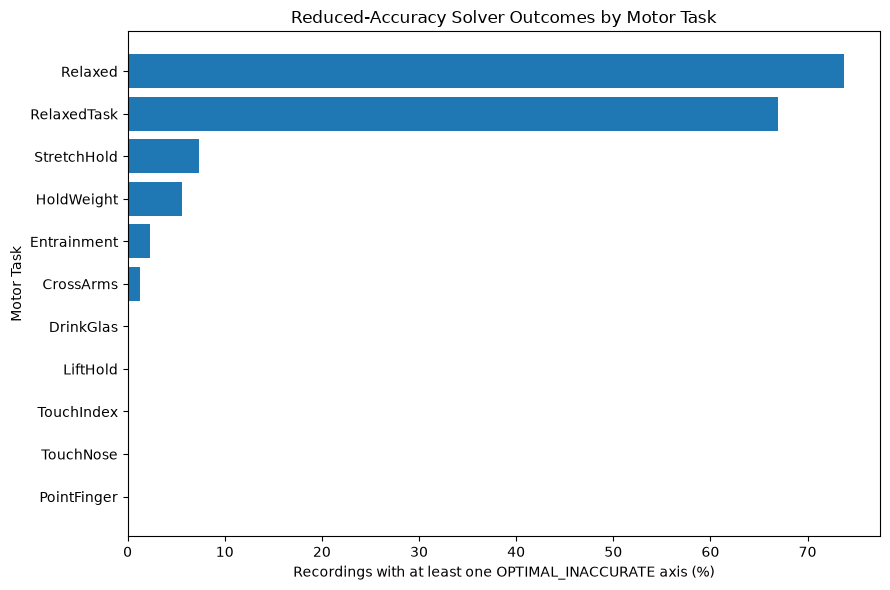

In [13]:
# Reduced-accuracy percentage by task
# =============================================================================
plot_data = (
    task_solver_summary
    .sort_values(
        "Reduced_Accuracy_Percentage"
    )
)

plt.figure(figsize=(9, 6))
plt.barh(
    plot_data.index,
    plot_data[
        "Reduced_Accuracy_Percentage"
    ],
)
plt.xlabel("Recordings with at least one OPTIMAL_INACCURATE axis (%)")
plt.ylabel("Motor Task")
plt.title("Reduced-Accuracy Solver Outcomes by Motor Task")
plt.tight_layout()
plt.show()

The pattern does not appear to be explained solely by recording length. `Relaxed`, `RelaxedTask`, and `Entrainment` all contain 2,000 processed samples, yet reduced-accuracy outcomes occurred in 73.77%, 66.95%, and only 2.35% of their recordings, respectively. This suggests that solver behavior is more closely related to signal characteristics than recording duration alone.

### Task-Level Pattern

Reduced-accuracy solver outcomes were strongly concentrated in the two low-movement tasks.

- `Relaxed`: 692 of 938 recordings (73.77%) contained at least one `optimal_inaccurate` axis.
- `RelaxedTask`: 628 of 938 recordings (66.95%) contained at least one `optimal_inaccurate` axis.

Together, these two tasks accounted for the large majority of reduced-accuracy recording-level outcomes.

In contrast, `LiftHold`, `PointFinger`, `TouchIndex`, and `TouchNose` achieved fully optimal solver status for every recording.

This pattern suggests that reduced numerical accuracy was task-dependent rather than randomly distributed throughout the wearable dataset.

Importantly, none of these tasks produced a true preprocessing failure.

## 6. Solver Status by Wrist

Because recordings were collected independently from the left and right wrists, preprocessing outcomes should also be examined by recording location.

This check helps determine whether reduced-accuracy solver outcomes are disproportionately associated with one wrist.

In [14]:
# Status by wrist
# =============================================================================
wrist_status = pd.crosstab(report["wrist"],report["status"],)
wrist_status

status,PASSED_INACCURATE,PASSED_OPTIMAL
wrist,,
LeftWrist,701,4458
RightWrist,776,4383


In [15]:
# Status percentages by wrist
# =============================================================================
wrist_status_pct = (
    pd.crosstab(
        report["wrist"],
        report["status"],
        normalize="index",
    )
    * 100
).round(2)
wrist_status_pct

status,PASSED_INACCURATE,PASSED_OPTIMAL
wrist,,
LeftWrist,13.59,86.41
RightWrist,15.04,84.96


Reduced-accuracy outcomes were observed at similar rates for the left and right wrists (13.59% and 15.04%, respectively). No strong wrist-specific preprocessing pattern was evident at this stage.

## 7. Processing Time

Processing time was recorded for each task–wrist signal.

This provides a computational performance summary of the final preprocessing implementation and helps confirm that the participant-level signal cache avoids the need to repeatedly perform L1 trend filtering during later feature engineering.

In [16]:
# Processing time summary
# =============================================================================
processing_time_summary = (
    report[
        "processing_time_seconds"
    ]
    .describe()
    .to_frame(
        name="Processing Time (seconds)"
    )
)
processing_time_summary

,Processing Time (seconds)
count,10318.000000
mean,0.370055
std,0.168822
min,0.211500
25%,0.262600
50%,0.298200
75%,0.441175
max,2.352200


In [17]:
# Processing time by task
# =============================================================================

time_by_task = (
    report
    .groupby("task")[
        "processing_time_seconds"
    ]
    .agg(
        [
            "mean",
            "median",
            "max",
        ]
    )
    .round(3)
    .sort_values(
        "mean",
        ascending=False,
    )
)
time_by_task

,mean,median,max
task,,,
Entrainment,0.560,0.503,2.249
Relaxed,0.557,0.491,2.352
RelaxedTask,0.538,0.477,1.931
CrossArms,0.333,0.301,1.737
DrinkGlas,0.323,0.291,1.670
LiftHold,0.314,0.284,1.438
PointFinger,0.290,0.264,1.039
HoldWeight,0.289,0.257,1.858
StretchHold,0.289,0.252,1.065


In [18]:
# Numerical warnings
# =============================================================================

print(
    "Total solver warnings recorded:",
    int(
        report[
            "solver_warning_count"
        ].sum()
    ),
)

print(
    "Recordings containing a reduced-accuracy solution:",
    int(
        report[
            "has_optimal_inaccurate"
        ].sum()
    ),
)

Total solver warnings recorded: 2310
Recordings containing a reduced-accuracy solution: 1477


## 8. Participant-Level `.npz` Signal Cache

Performing L1 trend filtering repeatedly during feature engineering would be computationally unnecessary.

The processed recordings were therefore cached as compressed NumPy (`.npz`) files.

One `.npz` file is generated for each participant and contains:

- 22 task–wrist recordings,
- nine processed signal columns,
- the task–wrist recording keys,
- and the column names.

The 22 recordings correspond to:

**11 motor tasks × 2 wrists**

The arrays are stored separately because the motor tasks have different recording durations.

In [19]:
# Select one participant NPZ for inspection
# =============================================================================

sample_participant = "011"

sample_npz_path = (
    NPZ_DIR
    / f"{sample_participant}_preprocessed.npz"
)

print(
    "Sample NPZ:",
    sample_npz_path,
)

print(
    "Exists:",
    sample_npz_path.exists(),
)

Sample NPZ: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed\preprocessed_signals\011_preprocessed.npz
Exists: True


In [20]:
# Inspect NPZ contents
# =============================================================================

with np.load(
    sample_npz_path,
    allow_pickle=False,
) as data:

    npz_keys = data.files


print(
    "Number of entries stored:",
    len(npz_keys),
)

print("\nNPZ keys:")

for key in npz_keys:
    print(key)

Number of entries stored: 24

NPZ keys:
__columns__
__recording_keys__
CrossArms__LeftWrist
CrossArms__RightWrist
DrinkGlas__LeftWrist
DrinkGlas__RightWrist
Entrainment__LeftWrist
Entrainment__RightWrist
HoldWeight__LeftWrist
HoldWeight__RightWrist
LiftHold__LeftWrist
LiftHold__RightWrist
PointFinger__LeftWrist
PointFinger__RightWrist
Relaxed__LeftWrist
Relaxed__RightWrist
RelaxedTask__LeftWrist
RelaxedTask__RightWrist
StretchHold__LeftWrist
StretchHold__RightWrist
TouchIndex__LeftWrist
TouchIndex__RightWrist
TouchNose__LeftWrist
TouchNose__RightWrist


In [21]:
# Stored metadata
# =============================================================================

with np.load(
    sample_npz_path,
    allow_pickle=False,
) as data:

    signal_columns = data[
        "__columns__"
    ]

    recording_keys = data[
        "__recording_keys__"
    ]


print("Signal columns:")

for column in signal_columns:
    print("-", column)


print(
    "\nNumber of task-wrist recordings:",
    len(recording_keys),
)


print("\nRecording keys:")

for key in recording_keys:
    print("-", key)

Signal columns:
- Time
- Accelerometer_X
- Accelerometer_Y
- Accelerometer_Z
- Gyroscope_X
- Gyroscope_Y
- Gyroscope_Z
- Acc_Magnitude
- Gyro_Magnitude

Number of task-wrist recordings: 22

Recording keys:
- CrossArms__LeftWrist
- CrossArms__RightWrist
- DrinkGlas__LeftWrist
- DrinkGlas__RightWrist
- Entrainment__LeftWrist
- Entrainment__RightWrist
- HoldWeight__LeftWrist
- HoldWeight__RightWrist
- LiftHold__LeftWrist
- LiftHold__RightWrist
- PointFinger__LeftWrist
- PointFinger__RightWrist
- RelaxedTask__LeftWrist
- RelaxedTask__RightWrist
- Relaxed__LeftWrist
- Relaxed__RightWrist
- StretchHold__LeftWrist
- StretchHold__RightWrist
- TouchIndex__LeftWrist
- TouchIndex__RightWrist
- TouchNose__LeftWrist
- TouchNose__RightWrist


## 9. Processed Signal Structure

Each task–wrist recording is represented by a two-dimensional array containing nine channels:

| Column | Description |
|---|---|
| `Time` | Re-zeroed recording time |
| `Accelerometer_X` | Preprocessed accelerometer X axis |
| `Accelerometer_Y` | Preprocessed accelerometer Y axis |
| `Accelerometer_Z` | Preprocessed accelerometer Z axis |
| `Gyroscope_X` | Original gyroscope X axis |
| `Gyroscope_Y` | Original gyroscope Y axis |
| `Gyroscope_Z` | Original gyroscope Z axis |
| `Acc_Magnitude` | Accelerometer vector magnitude |
| `Gyro_Magnitude` | Gyroscope vector magnitude |

The accelerometer axes have undergone L1 trend removal, while the gyroscope signals are preserved apart from the initial 48-sample trimming.

In [22]:
# Select one example processed recording
# =============================================================================

sample_row = (
    report[
        (report["task"] == "TouchNose")
        & (report["wrist"] == "LeftWrist")
        & (report["status"] == "PASSED_OPTIMAL")
    ]
    .iloc[0]
)

sample_participant = (
    sample_row[
        "patient_id"
    ]
)

recording_key = (
    sample_row[
        "npz_key"
    ]
)

raw_file_name = (
    sample_row[
        "input_file"
    ]
)

sample_npz_path = (
    NPZ_DIR
    / f"{sample_participant}_preprocessed.npz"
)

print(
    "Participant:",
    sample_participant,
)

print(
    "Recording:",
    recording_key,
)

print(
    "Raw file:",
    raw_file_name,
)

Participant: 001
Recording: TouchNose__LeftWrist
Raw file: 001_TouchNose_LeftWrist.txt


In [23]:
# Convert processed array to DataFrame
# =============================================================================

with np.load(
    sample_npz_path,
    allow_pickle=False,
) as data:

    signal_array = data[
        recording_key
    ]

    signal_columns = data[
        "__columns__"
    ]


signal_df = pd.DataFrame(
    signal_array,
    columns=signal_columns,
)


print(
    "Processed recording shape:",
    signal_df.shape,
)

signal_df.head()

Processed recording shape: (976, 9)


,Time,Accelerometer_X,Accelerometer_Y,Accelerometer_Z,Gyroscope_X,Gyroscope_Y,Gyroscope_Z,Acc_Magnitude,Gyro_Magnitude
0,0.000000,0.019449,0.040921,-0.141899,0.777211,-1.104243,-0.581635,0.148957,1.470275
1,0.009984,0.024988,-0.018355,-0.135501,0.678674,-0.982109,-0.459121,0.139003,1.279034
2,0.020034,0.024623,-0.040875,-0.096214,0.555866,-0.887033,-0.353409,0.107397,1.104859
3,0.029983,0.033150,-0.063856,-0.039413,0.493961,-0.789562,-0.273257,0.082037,0.970605
4,0.040020,0.044065,-0.076894,-0.035761,0.473266,-0.759354,-0.222446,0.095568,0.921998


In [24]:
# Processed recording descriptive statistics
# =============================================================================
signal_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,976.0,4.872803,2.817614,0.000000,2.436427,4.872796,7.309147,9.745538
Accelerometer_X,976.0,0.000213,0.139321,-0.799545,-0.088515,0.019638,0.096324,0.387283
Accelerometer_Y,976.0,-0.001111,0.217733,-0.888067,-0.134080,-0.024324,0.128377,0.871901
Accelerometer_Z,976.0,-0.000004,0.222880,-0.779837,-0.150514,-0.035421,0.149492,0.631443
Gyroscope_X,976.0,-0.069384,2.834926,-10.478931,-1.239911,0.099464,0.978529,6.799439
Gyroscope_Y,976.0,-0.411828,1.791027,-3.905093,-1.872173,-0.427244,0.733689,4.151290
Gyroscope_Z,976.0,0.279209,3.236900,-6.996271,-1.197172,-0.079452,2.315511,6.756719
Acc_Magnitude,976.0,0.296339,0.169079,0.042989,0.171131,0.257639,0.375961,1.202944
Gyro_Magnitude,976.0,3.764154,2.791300,0.048635,1.204579,3.253962,6.029927,12.597110


## 10. Recording Lengths

The original PADS motor recordings contain either 1,024 or 2,048 samples depending on the task.

The preprocessing pipeline removes the first 48 samples from every recording.

Consequently:

- 1,024-sample recordings become **976 samples**.
- 2,048-sample recordings become **2,000 samples**.

The different post-processing durations are intentionally preserved.

This project performs feature extraction separately by task and wrist, so the raw signals do not need to be forced into a common fixed-length matrix.

In [25]:
# Processed sample counts by motor task
# =============================================================================

task_length_summary = (
    report
    .groupby("task")
    .agg(
        Recordings=(
            "processed_samples",
            "size",
        ),
        Minimum_Samples=(
            "processed_samples",
            "min",
        ),
        Maximum_Samples=(
            "processed_samples",
            "max",
        ),
        Unique_Lengths=(
            "processed_samples",
            "nunique",
        ),
    )
    .sort_values(
        "Maximum_Samples",
        ascending=False,
    )
)

task_length_summary

,Recordings,Minimum_Samples,Maximum_Samples,Unique_Lengths
task,,,,
Entrainment,938,2000,2000,1
RelaxedTask,938,2000,2000,1
Relaxed,938,2000,2000,1
DrinkGlas,938,976,976,1
CrossArms,938,976,976,1
LiftHold,938,976,976,1
HoldWeight,938,976,976,1
PointFinger,938,976,976,1
StretchHold,938,976,976,1


In [26]:
# Inspect shapes of all recordings for the sample participant
# =============================================================================
recording_shapes = []
with np.load(
    sample_npz_path,
    allow_pickle=False,
) as data:

    for key in data[
        "__recording_keys__"
    ]:
        key = str(key)
        task, wrist = (
            key.split("__")
        )
        array = data[key]
        recording_shapes.append(
            {
                "task": task,
                "wrist": wrist,
                "samples": array.shape[0],
                "columns": array.shape[1],
            }
        )


shape_df = pd.DataFrame(
    recording_shapes
)

shape_df.sort_values(
    [
        "samples",
        "task",
        "wrist",
    ],
    ascending=[
        False,
        True,
        True,
    ],
)

,task,wrist,samples,columns
4,Entrainment,LeftWrist,2000,9
5,Entrainment,RightWrist,2000,9
14,Relaxed,LeftWrist,2000,9
15,Relaxed,RightWrist,2000,9
12,RelaxedTask,LeftWrist,2000,9
13,RelaxedTask,RightWrist,2000,9
0,CrossArms,LeftWrist,976,9
1,CrossArms,RightWrist,976,9
2,DrinkGlas,LeftWrist,976,9
3,DrinkGlas,RightWrist,976,9


## 11. Visual Inspection of the Processed Accelerometer Signal

The following plot shows the three preprocessed accelerometer axes for one example movement recording.

At this stage:

- the slowly varying accelerometer trend has been removed,
- the first 48 samples have been removed,
- and time begins at zero.

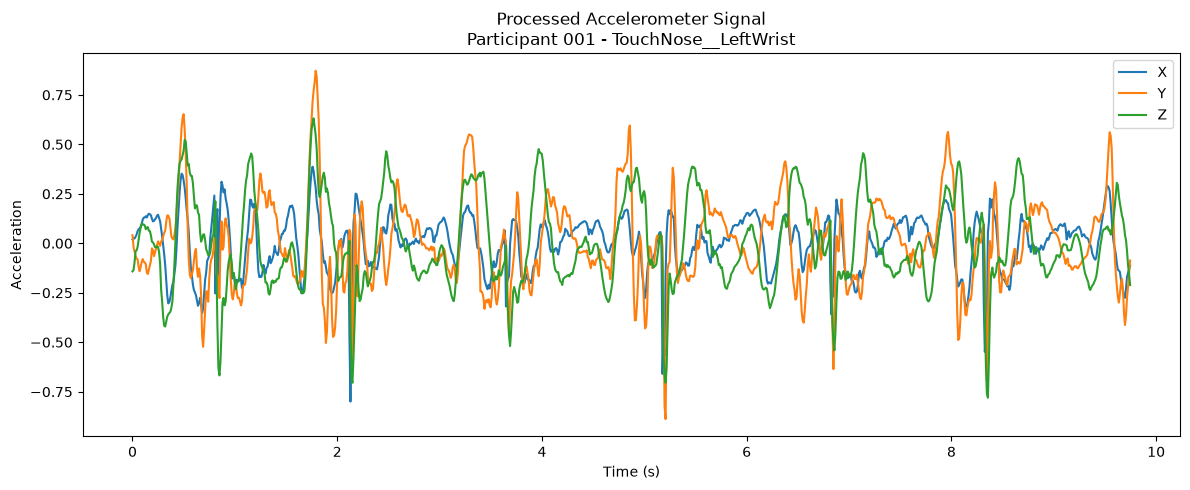

In [27]:
# Processed accelerometer axes
# =============================================================================

plt.figure(
    figsize=(12, 5)
)
plt.plot(
    signal_df["Time"],
    signal_df["Accelerometer_X"],
    label="X",
)
plt.plot(signal_df["Time"],
    signal_df["Accelerometer_Y"],
    label="Y",
)
plt.plot(signal_df["Time"],
    signal_df["Accelerometer_Z"],
    label="Z",
)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.title(
    "Processed Accelerometer Signal\n"
    f"Participant {sample_participant} - "
    f"{recording_key}"
)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Signal Magnitude

Vector magnitude was added to provide an orientation-independent representation of overall sensor activity.

Accelerometer magnitude is calculated as:

\[
|a| = \sqrt{a_x^2 + a_y^2 + a_z^2}
\]

Gyroscope magnitude is calculated as:

\[
|g| = \sqrt{g_x^2 + g_y^2 + g_z^2}
\]

These magnitude channels will be available alongside the individual X, Y, and Z axes during feature extraction.

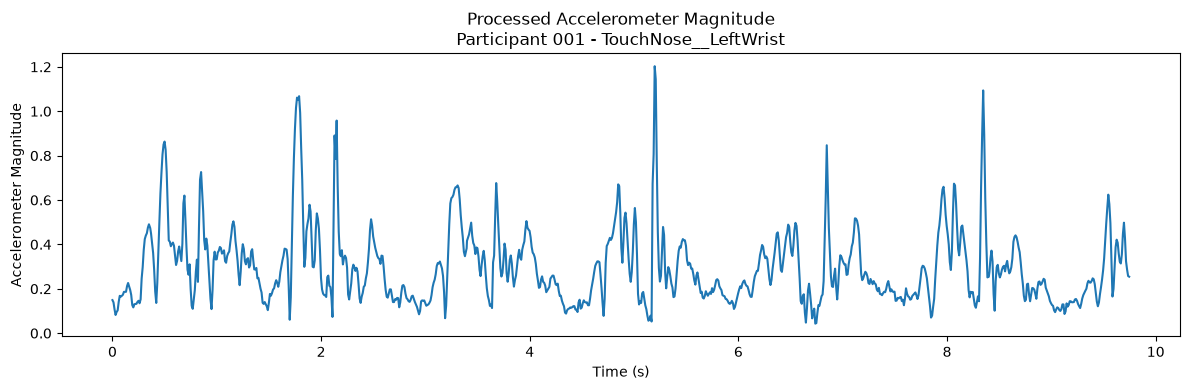

In [28]:
# Accelerometer magnitude
# =============================================================================

plt.figure(figsize=(12, 4))
plt.plot(
    signal_df["Time"],
    signal_df["Acc_Magnitude"],
)
plt.xlabel("Time (s)")
plt.ylabel("Accelerometer Magnitude")
plt.title(
    "Processed Accelerometer Magnitude\n"
    f"Participant {sample_participant} - "
    f"{recording_key}"
)
plt.tight_layout()
plt.show()

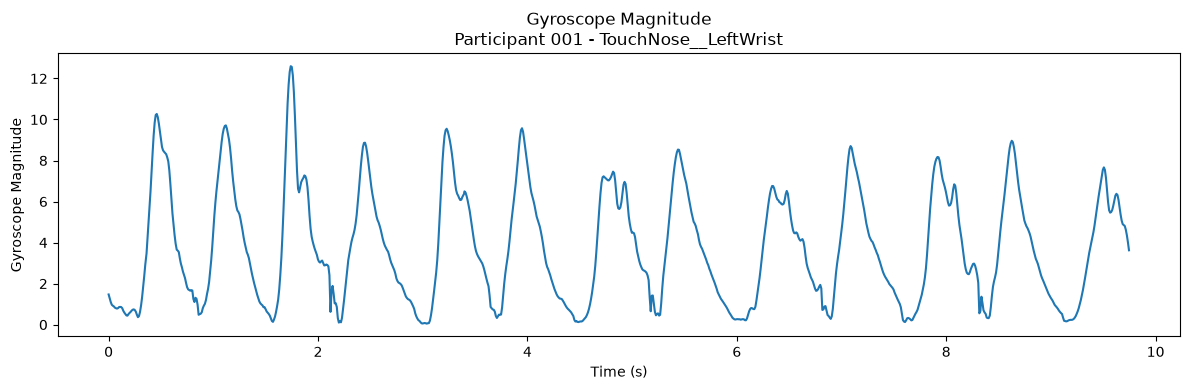

In [29]:
# Gyroscope magnitude
# =============================================================================
plt.figure(figsize=(12, 4))
plt.plot(
    signal_df["Time"],
    signal_df["Gyro_Magnitude"],
)
plt.xlabel("Time (s)")
plt.ylabel("Gyroscope Magnitude")
plt.title(
    "Gyroscope Magnitude\n"
    f"Participant {sample_participant} - "
    f"{recording_key}"
)
plt.tight_layout()
plt.show()

In [30]:
# Independent magnitude validation
# =============================================================================

expected_acc_magnitude = np.sqrt(
    signal_df["Accelerometer_X"] ** 2
    + signal_df["Accelerometer_Y"] ** 2
    + signal_df["Accelerometer_Z"] ** 2
)

expected_gyro_magnitude = np.sqrt(
    signal_df["Gyroscope_X"] ** 2
    + signal_df["Gyroscope_Y"] ** 2
    + signal_df["Gyroscope_Z"] ** 2
)


acc_magnitude_valid = np.allclose(
    signal_df["Acc_Magnitude"],
    expected_acc_magnitude,
)

gyro_magnitude_valid = np.allclose(
    signal_df["Gyro_Magnitude"],
    expected_gyro_magnitude,
)


print(
    "Accelerometer magnitude valid:",
    acc_magnitude_valid,
)

print(
    "Gyroscope magnitude valid:",
    gyro_magnitude_valid,
)

Accelerometer magnitude valid: True
Gyroscope magnitude valid: True


## 13. Raw vs. Processed Accelerometer Signal

One raw recording is now compared with its processed counterpart.

For a fair comparison, the raw signal is:

1. trimmed by the same 48 samples,
2. re-indexed,
3. and its time channel is re-zeroed.

The remaining difference between the aligned raw accelerometer signal and the processed accelerometer signal represents the slowly varying component removed by the L1 trend filter.

In [31]:
# Load corresponding raw recording
# =============================================================================

RAW_COLUMNS = [
    "Time",
    "Accelerometer_X",
    "Accelerometer_Y",
    "Accelerometer_Z",
    "Gyroscope_X",
    "Gyroscope_Y",
    "Gyroscope_Z",
]


raw_path = (
    RAW_DIR
    / raw_file_name
)

raw_signal = pd.read_csv(
    raw_path,
    header=None,
    names=RAW_COLUMNS,
)


print(
    "Raw recording shape:",
    raw_signal.shape,
)

raw_signal.head()

Raw recording shape: (1024, 7)


,Time,Accelerometer_X,Accelerometer_Y,Accelerometer_Z,Gyroscope_X,Gyroscope_Y,Gyroscope_Z
0,0.000000,-0.314262,-0.406344,-0.647017,1.169301,0.751087,-0.456878
1,0.009687,-0.187177,-0.592680,-0.430099,0.724863,0.728832,-0.282192
2,0.019858,-0.221640,-0.550364,-0.347897,0.449836,0.680792,-0.276376
3,0.029833,-0.190459,-0.423449,-0.322618,0.499378,0.547535,-0.409425
4,0.039866,-0.193140,-0.320662,-0.314953,0.751616,0.513395,-0.755720


In [32]:
# Align raw signal with processed signal
# =============================================================================

raw_aligned = (
    raw_signal
    .iloc[48:]
    .copy()
    .reset_index(drop=True)
)
raw_aligned["Time"] = (
    raw_aligned["Time"]
    - raw_aligned["Time"].iloc[0]
)
print(
    "Aligned raw shape:",
    raw_aligned.shape,
)
print(
    "Processed shape:",
    signal_df.shape,
)

Aligned raw shape: (976, 7)
Processed shape: (976, 9)


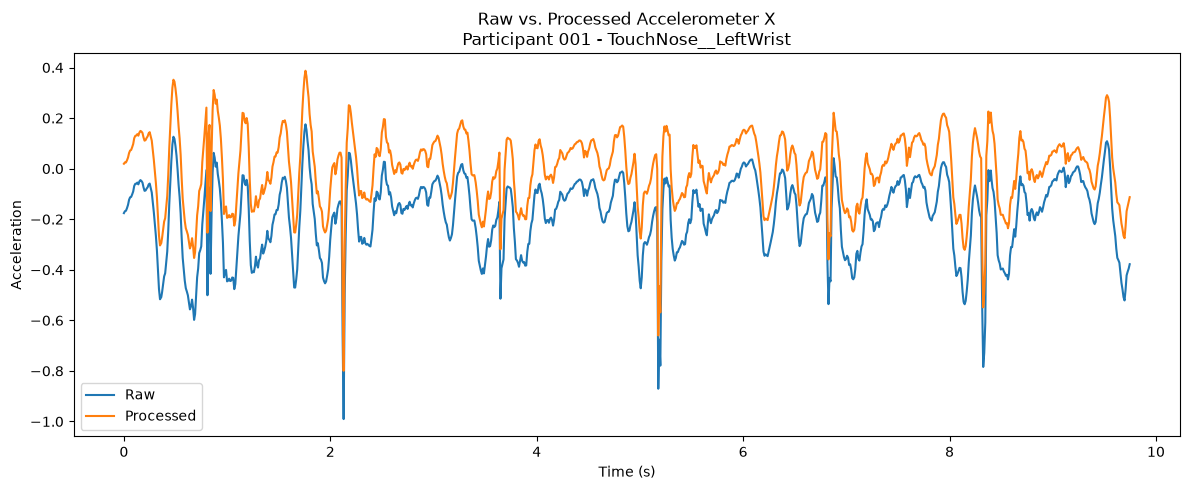

In [33]:
# Raw versus processed accelerometer X
# =============================================================================
plt.figure(figsize=(12, 5))
plt.plot(
    raw_aligned["Time"],
    raw_aligned["Accelerometer_X"],
    label="Raw",
)
plt.plot(
    signal_df["Time"],
    signal_df["Accelerometer_X"],
    label="Processed",
)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.title(
    "Raw vs. Processed Accelerometer X\n"
    f"Participant {sample_participant} - "
    f"{recording_key}"
)
plt.legend()
plt.tight_layout()
plt.show()

## 14. Estimated Trend Removed by L1 Filtering

Because the raw and processed signals are aligned after trimming, the slowly varying component estimated by the L1 trend filter can be reconstructed as:

Estimated Trend = Raw Accelerometer - Processed Accelerometer

This provides a direct visual representation of the baseline component removed during accelerometer preprocessing.

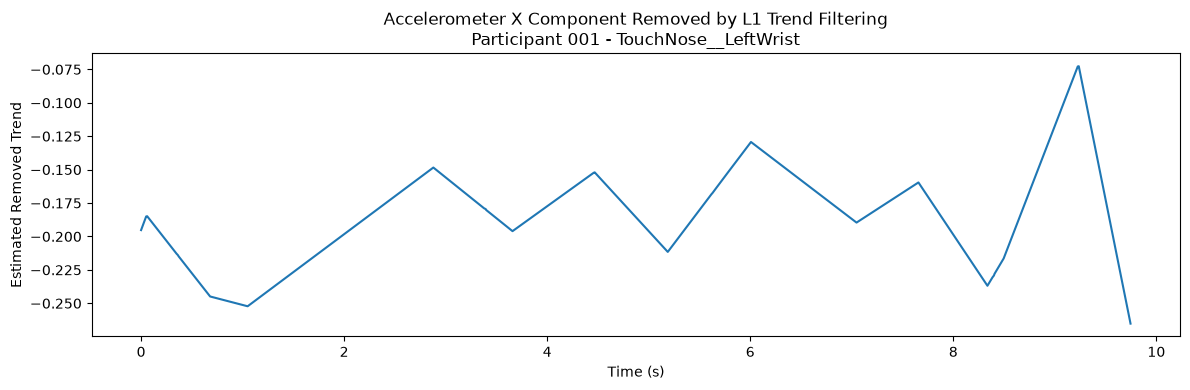

In [34]:
# Reconstruct the removed accelerometer trend
# =============================================================================

removed_trend_x = (
    raw_aligned[
        "Accelerometer_X"
    ].to_numpy()
    - signal_df[
        "Accelerometer_X"
    ].to_numpy()
)


plt.figure(
    figsize=(12, 4)
)

plt.plot(
    signal_df["Time"],
    removed_trend_x,
)
plt.xlabel("Time (s)")
plt.ylabel("Estimated Removed Trend")
plt.title(
    "Accelerometer X Component Removed by L1 Trend Filtering\n"
    f"Participant {sample_participant} - "
    f"{recording_key}"
)
plt.tight_layout()
plt.show()

## 15. Gyroscope Preservation Check

The L1 trend filter is applied only to the accelerometer.

Gyroscope signals should therefore remain unchanged apart from removal of the first 48 samples.

The following check directly compares the aligned raw gyroscope channels with the stored processed gyroscope channels.

In [35]:
# Verify that gyroscope channels were preserved
# =============================================================================
GYRO_COLUMNS = [
    "Gyroscope_X",
    "Gyroscope_Y",
    "Gyroscope_Z",
]
gyro_validation = []
for column in GYRO_COLUMNS:
    difference = np.abs(
        raw_aligned[
            column
        ].to_numpy()
        - signal_df[
            column
        ].to_numpy()
    )
    gyro_validation.append(
        {
            "Channel": column,
            "Maximum Absolute Difference":
                difference.max(),
            "Mean Absolute Difference":
                difference.mean(),
            "Unchanged":
                np.allclose(
                    raw_aligned[
                        column
                    ].to_numpy(),
                    signal_df[
                        column
                    ].to_numpy(),
                ),
        }
    )

gyro_validation_df = pd.DataFrame(
    gyro_validation
)
gyro_validation_df

,Channel,Maximum Absolute Difference,Mean Absolute Difference,Unchanged
0,Gyroscope_X,0.0,0.0,True
1,Gyroscope_Y,0.0,0.0,True
2,Gyroscope_Z,0.0,0.0,True


In [36]:
# Time-channel validation
# =============================================================================

print(
    "Processed signal begins at:",
    signal_df["Time"].iloc[0],
)
print(
    "Time values finite:",
    np.isfinite(
        signal_df["Time"]
    ).all(),
)
assert np.isclose(
    signal_df["Time"].iloc[0],
    0.0,
)

Processed signal begins at: 0.0
Time values finite: True


## 16. Complete `.npz` Cache Integrity Validation

A participant-level `.npz` file should contain:

- exactly 22 task–wrist recordings,
- nine columns per recording,
- finite numeric values,
- and the same expected signal columns.

The following validation scans all participant cache files without loading the complete processed dataset into memory at once.

In [37]:
# Dataset-wide NPZ integrity scan
# =============================================================================
EXPECTED_RECORDINGS_PER_PARTICIPANT = 22
EXPECTED_SIGNAL_COLUMNS = 9
npz_validation = []
for npz_path in sorted(
    NPZ_DIR.glob(
        "*_preprocessed.npz"
    )
):
    patient_id = (
        npz_path.stem
        .replace(
            "_preprocessed",
            "",
        )
    )
    try:
        with np.load(
            npz_path,
            allow_pickle=False,
        ) as data:
            columns = data[
                "__columns__"
            ]
            keys = data[
                "__recording_keys__"
            ]
            recording_count = (
                len(keys)
            )
            correct_recording_count = (
                recording_count
                == EXPECTED_RECORDINGS_PER_PARTICIPANT
            )
            correct_column_metadata = (
                len(columns)
                == EXPECTED_SIGNAL_COLUMNS
            )
            all_shapes_valid = True
            all_values_finite = True
            for key in keys:
                array = data[
                    str(key)
                ]
                if (
                    array.ndim != 2
                    or array.shape[1]
                    != EXPECTED_SIGNAL_COLUMNS
                ):
                    all_shapes_valid = False

                if not np.isfinite(
                    array
                ).all():
                    all_values_finite = False

        valid = all(
            [
                correct_recording_count,
                correct_column_metadata,
                all_shapes_valid,
                all_values_finite,
            ]
        )

        npz_validation.append(
            {
                "patient_id":
                    patient_id,

                "recordings":
                    recording_count,

                "correct_recording_count":
                    correct_recording_count,

                "correct_column_metadata":
                    correct_column_metadata,

                "all_shapes_valid":
                    all_shapes_valid,

                "all_values_finite":
                    all_values_finite,

                "valid":
                    valid,

                "error":
                    "None",
            }
        )


    except Exception as exc:

        npz_validation.append(
            {
                "patient_id":
                    patient_id,

                "recordings":
                    np.nan,

                "correct_recording_count":
                    False,

                "correct_column_metadata":
                    False,

                "all_shapes_valid":
                    False,

                "all_values_finite":
                    False,

                "valid":
                    False,

                "error":
                    str(exc),
            }
        )


npz_validation_df = pd.DataFrame(
    npz_validation
)

npz_validation_df.head()

,patient_id,recordings,correct_recording_count,correct_column_metadata,all_shapes_valid,all_values_finite,valid,error
0,001,22,True,True,True,True,True,None
1,002,22,True,True,True,True,True,None
2,003,22,True,True,True,True,True,None
3,004,22,True,True,True,True,True,None
4,005,22,True,True,True,True,True,None


In [38]:
# NPZ validation summary
# =============================================================================

npz_summary = pd.DataFrame(
    {
        "Metric": [
            "NPZ files checked",
            "Valid NPZ files",
            "Invalid NPZ files",
            "Files with 22 recordings",
            "Files with finite values",
            "Files with valid array shapes",
        ],
        "Count": [
            len(npz_validation_df),

            npz_validation_df[
                "valid"
            ].sum(),

            (
                ~npz_validation_df[
                    "valid"
                ]
            ).sum(),

            npz_validation_df[
                "correct_recording_count"
            ].sum(),

            npz_validation_df[
                "all_values_finite"
            ].sum(),

            npz_validation_df[
                "all_shapes_valid"
            ].sum(),
        ],
    }
)

npz_summary

,Metric,Count
0,NPZ files checked,469
1,Valid NPZ files,469
2,Invalid NPZ files,0
3,Files with 22 recordings,469
4,Files with finite values,469
5,Files with valid array shapes,469


## 17. Participant-Level Completeness

Before feature extraction, every participant should have all 22 task–wrist recordings available.

This check compares recording counts in the preprocessing report and confirms that every participant received a completed `.npz` cache file.

In [39]:
# Participant-level completeness
# =============================================================================

recordings_per_participant = (
    report
    .groupby(
        "patient_id"
    )
    .size()
)
participant_summary = pd.DataFrame(
    {
        "Metric": [
            "Participants",
            "Minimum recordings per participant",
            "Maximum recordings per participant",
            "Participants with exactly 22 recordings",
            "Participants marked as NPZ saved",
        ],
        "Value": [
            report[
                "patient_id"
            ].nunique(),
            recordings_per_participant.min(),
            recordings_per_participant.max(),
            (
                recordings_per_participant
                == 22
            ).sum(),

            report[
                report[
                    "participant_npz_saved"
                ]
            ][
                "patient_id"
            ].nunique(),
        ],
    }
)
participant_summary

,Metric,Value
0,Participants,469
1,Minimum recordings per participant,22
2,Maximum recordings per participant,22
3,Participants with exactly 22 recordings,469
4,Participants marked as NPZ saved,469


## 18. Final Dataset Integrity Check

The final processed wearable cache should satisfy all of the following conditions:

- 469 unique participants,
- 10,318 smartwatch recordings,
- 469 participant `.npz` files,
- 22 recordings per participant,
- no preprocessing failures,
- no missing participant cache files,
- valid numeric arrays,
- and nine processed channels per recording.

In [40]:
# Final dataset-level integrity assertions
# =============================================================================

EXPECTED_PARTICIPANTS = 469
EXPECTED_RECORDINGS = 10318
EXPECTED_NPZ_FILES = 469
EXPECTED_RECORDINGS_PER_PARTICIPANT = 22


assert (
    report[
        "patient_id"
    ].nunique()
    == EXPECTED_PARTICIPANTS
)

assert (
    len(report)
    == EXPECTED_RECORDINGS
)

assert (
    len(npz_files)
    == EXPECTED_NPZ_FILES
)

assert (
    recordings_per_participant.min()
    == EXPECTED_RECORDINGS_PER_PARTICIPANT
)

assert (
    recordings_per_participant.max()
    == EXPECTED_RECORDINGS_PER_PARTICIPANT
)

assert (
    (
        report["status"]
        == "FAILED"
    ).sum()
    == 0
)

assert (
    report[
        "participant_npz_saved"
    ].all()
)

assert (
    npz_validation_df[
        "valid"
    ].all()
)


print(
    "Dataset-level preprocessing integrity checks passed."
)

Dataset-level preprocessing integrity checks passed.


In [41]:
# Final preprocessing dashboard
# =============================================================================
optimal_recordings = (
    report["status"]
    == "PASSED_OPTIMAL"
).sum()
inaccurate_recordings = (
    report["status"]
    == "PASSED_INACCURATE"
).sum()
failed_recordings = (
    report["status"]
    == "FAILED"
).sum()
final_summary = pd.DataFrame(
    {
        "Metric": [
            "Participants",
            "Recordings",
            "Motor tasks",
            "Wrists",
            "Participant NPZ files",
            "PASSED_OPTIMAL",
            "PASSED_INACCURATE",
            "FAILED",
            "Solver warnings",
            "Mean processing time (s)",
            "Median processing time (s)",
            "Maximum processing time (s)",
        ],
        "Value": [
            report[
                "patient_id"
            ].nunique(),

            len(report),

            report[
                "task"
            ].nunique(),

            report[
                "wrist"
            ].nunique(),

            len(npz_files),

            optimal_recordings,

            inaccurate_recordings,

            failed_recordings,

            int(
                report[
                    "solver_warning_count"
                ].sum()
            ),

            round(
                report[
                    "processing_time_seconds"
                ].mean(),
                3,
            ),

            round(
                report[
                    "processing_time_seconds"
                ].median(),
                3,
            ),

            round(
                report[
                    "processing_time_seconds"
                ].max(),
                3,
            ),
        ],
    }
)

final_summary

,Metric,Value
0,Participants,469.000
1,Recordings,10318.000
2,Motor tasks,11.000
3,Wrists,2.000
4,Participant NPZ files,469.000
5,PASSED_OPTIMAL,8841.000
6,PASSED_INACCURATE,1477.000
7,FAILED,0.000
8,Solver warnings,2310.000
9,Mean processing time (s),0.370


## 19. Visual Validation of OPTIMAL and OPTIMAL_INACCURATE Recordings

The dataset-wide preprocessing report classified successful recordings into two numerical status groups:

- `PASSED_OPTIMAL`: all three accelerometer axes returned `optimal`.
- `PASSED_INACCURATE`: at least one accelerometer axis returned `optimal_inaccurate`.

Because `PASSED_INACCURATE` recordings represent 14.31% of the wearable dataset, a small random sample was inspected to determine whether these processed signals display noticeable structural or visual abnormalities.

To make the groups as comparable as possible, recordings were selected from the same motor task and wrist. Three `PASSED_OPTIMAL` recordings and three `PASSED_INACCURATE` recordings were randomly selected using a fixed random seed.

The validation evaluates:

- processed recording dimensions,
- finite numeric values,
- time-channel continuity,
- constant accelerometer channels,
- accelerometer magnitude statistics,
- visual signal continuity,
- and raw-versus-processed signal behavior.

This comparison is intended to identify obvious signal-quality problems. Because the recordings belong to different participants, differences in amplitude or movement shape cannot be attributed exclusively to solver status.

In [42]:
# Random sample of PASSED_OPTIMAL and PASSED_INACCURATE recordings
# =============================================================================
VALIDATION_TASK = "Relaxed"
VALIDATION_WRIST = "LeftWrist"
SAMPLES_PER_STATUS = 3
RANDOM_STATE = 42
VALIDATION_STATUSES = [
    "PASSED_OPTIMAL",
    "PASSED_INACCURATE",
]
validation_candidates = report[
    (report["task"] == VALIDATION_TASK)
    & (report["wrist"] == VALIDATION_WRIST)
    & (report["status"].isin(VALIDATION_STATUSES))
].copy()
candidate_counts = (
    validation_candidates["status"]
    .value_counts()
    .reindex(VALIDATION_STATUSES)
)
print("Validation task:", VALIDATION_TASK)
print("Validation wrist:", VALIDATION_WRIST)
print("\nAvailable recordings:")
print(candidate_counts)

for status in VALIDATION_STATUSES:

    available_recordings = (
        validation_candidates["status"]
        == status
    ).sum()

    if available_recordings < SAMPLES_PER_STATUS:

        raise ValueError(
            f"Only {available_recordings} recordings are available "
            f"for {status}. At least {SAMPLES_PER_STATUS} are required."
        )

sampled_groups = []

for status_index, status in enumerate(VALIDATION_STATUSES):

    status_sample = (
        validation_candidates[
            validation_candidates["status"]
            == status
        ]
        .sample(
            n=SAMPLES_PER_STATUS,
            random_state=RANDOM_STATE + status_index,
        )
    )

    sampled_groups.append(status_sample)

validation_sample = (
    pd.concat(
        sampled_groups,
        ignore_index=True,
    )
    [
        [
            "patient_id",
            "task",
            "wrist",
            "input_file",
            "npz_key",
            "status",
            "acc_x_status",
            "acc_y_status",
            "acc_z_status",
        ]
    ]
)

validation_sample

Validation task: Relaxed
Validation wrist: LeftWrist

Available recordings:
status
PASSED_OPTIMAL       150
PASSED_INACCURATE    319
Name: count, dtype: int64


,patient_id,task,wrist,input_file,npz_key,status,acc_x_status,acc_y_status,acc_z_status
0,219,Relaxed,LeftWrist,219_Relaxed_LeftWrist.txt,Relaxed__LeftWrist,PASSED_OPTIMAL,optimal,optimal,optimal
1,062,Relaxed,LeftWrist,062_Relaxed_LeftWrist.txt,Relaxed__LeftWrist,PASSED_OPTIMAL,optimal,optimal,optimal
2,363,Relaxed,LeftWrist,363_Relaxed_LeftWrist.txt,Relaxed__LeftWrist,PASSED_OPTIMAL,optimal,optimal,optimal
3,291,Relaxed,LeftWrist,291_Relaxed_LeftWrist.txt,Relaxed__LeftWrist,PASSED_INACCURATE,optimal,optimal_inaccurate,optimal_inaccurate
4,341,Relaxed,LeftWrist,341_Relaxed_LeftWrist.txt,Relaxed__LeftWrist,PASSED_INACCURATE,optimal_inaccurate,optimal_inaccurate,optimal
5,279,Relaxed,LeftWrist,279_Relaxed_LeftWrist.txt,Relaxed__LeftWrist,PASSED_INACCURATE,optimal_inaccurate,optimal_inaccurate,optimal_inaccurate


### Structural and Descriptive Signal Checks

Each selected `.npz` recording is compared with its corresponding raw file.

The raw recording is trimmed by the same 48 samples used during preprocessing and its time channel is re-zeroed. The following checks are then performed on the processed signal:

- the processed and aligned raw recordings contain the same number of samples;
- all processed values are finite;
- processed time begins at zero;
- processed time remains strictly increasing;
- no accelerometer axis is constant;
- and the expected nine processed columns are present.

Basic accelerometer-magnitude statistics are also calculated to identify unusually flat or extreme signals.

In [43]:
# Load raw and processed recordings from the validation sample
# =============================================================================

RAW_VALIDATION_COLUMNS = [
    "Time",
    "Accelerometer_X",
    "Accelerometer_Y",
    "Accelerometer_Z",
    "Gyroscope_X",
    "Gyroscope_Y",
    "Gyroscope_Z",
]

EXPECTED_PROCESSED_COLUMNS = [
    "Time",
    "Accelerometer_X",
    "Accelerometer_Y",
    "Accelerometer_Z",
    "Gyroscope_X",
    "Gyroscope_Y",
    "Gyroscope_Z",
    "Acc_Magnitude",
    "Gyro_Magnitude",
]

ACCELEROMETER_AXES = [
    "Accelerometer_X",
    "Accelerometer_Y",
    "Accelerometer_Z",
]

INITIAL_SAMPLES_TO_REMOVE = 48


selected_signals = {}
validation_records = []


for _, row in validation_sample.iterrows():

    patient_id = str(row["patient_id"]).zfill(3)

    raw_path = (RAW_DIR/ row["input_file"])
    npz_path = (
        NPZ_DIR
        / f"{patient_id}_preprocessed.npz"
    )

    if not raw_path.exists():

        raise FileNotFoundError(
            f"Raw file not found: {raw_path}"
        )


    if not npz_path.exists():

        raise FileNotFoundError(
            f"Processed NPZ not found: {npz_path}"
        )


    # -------------------------------------------------------------------------
    # Load and align raw signal
    # -------------------------------------------------------------------------

    raw_signal = pd.read_csv(
        raw_path,
        header=None,
        names=RAW_VALIDATION_COLUMNS,
    )

    raw_aligned = (
        raw_signal
        .iloc[INITIAL_SAMPLES_TO_REMOVE:]
        .copy()
        .reset_index(drop=True)
    )

    raw_aligned["Time"] = (
        raw_aligned["Time"]
        - raw_aligned["Time"].iloc[0]
    )


    # -------------------------------------------------------------------------
    # Load processed signal
    # -------------------------------------------------------------------------

    with np.load(
        npz_path,
        allow_pickle=False,
    ) as data:

        processed_array = data[
            row["npz_key"]
        ]

        processed_columns = list(
            data["__columns__"]
        )


    processed_signal = pd.DataFrame(
        processed_array,
        columns=processed_columns,
    )


    # -------------------------------------------------------------------------
    # Structural checks
    # -------------------------------------------------------------------------

    shape_matches = (
        len(raw_aligned)
        == len(processed_signal)
    )

    expected_columns_present = (
        processed_columns
        == EXPECTED_PROCESSED_COLUMNS
    )

    all_values_finite = bool(
        np.isfinite(
            processed_signal.to_numpy()
        ).all()
    )

    time_starts_at_zero = bool(
        np.isclose(
            processed_signal["Time"].iloc[0],
            0.0,
        )
    )

    time_strictly_increasing = bool(
        (
            np.diff(
                processed_signal["Time"].to_numpy()
            )
            > 0
        ).all()
    )


    axis_standard_deviations = (
        processed_signal[
            ACCELEROMETER_AXES
        ]
        .std(ddof=1)
    )

    any_constant_accelerometer_axis = bool(
        (
            axis_standard_deviations
            == 0
        ).any()
    )


    # -------------------------------------------------------------------------
    # Accelerometer-magnitude statistics
    # -------------------------------------------------------------------------

    acc_magnitude = (
        processed_signal[
            "Acc_Magnitude"
        ]
        .to_numpy()
    )

    magnitude_rms = float(
        np.sqrt(
            np.mean(
                acc_magnitude ** 2
            )
        )
    )


    recording_key = (
        f"{row['status']}__"
        f"{patient_id}__"
        f"{row['task']}__"
        f"{row['wrist']}"
    )


    selected_signals[
        recording_key
    ] = {
        "patient_id":patient_id,
        "status": row["status"],
        "raw":raw_aligned,
        "processed": processed_signal,
    }


    validation_records.append(
        {
            "patient_id": patient_id,
            "status": row["status"],
            "task": row["task"],
            "wrist": row["wrist"],
            "processed_samples": len(processed_signal),
            "shape_matches_raw": shape_matches,
            "expected_columns_present": expected_columns_present,
            "all_values_finite":all_values_finite,
            "time_starts_at_zero": time_starts_at_zero,
            "time_strictly_increasing": time_strictly_increasing,
            "any_constant_acc_axis": any_constant_accelerometer_axis,
            "minimum_acc_axis_std": axis_standard_deviations.min(),
            "acc_magnitude_mean": acc_magnitude.mean(),
            "acc_magnitude_std": acc_magnitude.std(ddof=1),
            "acc_magnitude_rms": magnitude_rms,
            "acc_magnitude_min": acc_magnitude.min(),
            "acc_magnitude_max": acc_magnitude.max(),
            "acc_magnitude_range": np.ptp(acc_magnitude),
        }
    )


sample_validation_results = pd.DataFrame(
    validation_records
)
sample_validation_results

,patient_id,status,task,wrist,processed_samples,shape_matches_raw,expected_columns_present,all_values_finite,time_starts_at_zero,time_strictly_increasing,any_constant_acc_axis,minimum_acc_axis_std,acc_magnitude_mean,acc_magnitude_std,acc_magnitude_rms,acc_magnitude_min,acc_magnitude_max,acc_magnitude_range
0,219,PASSED_OPTIMAL,Relaxed,LeftWrist,2000,True,True,True,True,True,False,0.052420,0.057111,0.096229,0.111880,0.000551,1.252626,1.252074
1,062,PASSED_OPTIMAL,Relaxed,LeftWrist,2000,True,True,True,True,True,False,0.002010,0.009146,0.008135,0.012239,0.000273,0.066576,0.066303
2,363,PASSED_OPTIMAL,Relaxed,LeftWrist,2000,True,True,True,True,True,False,0.001401,0.002673,0.001418,0.003026,0.000204,0.011758,0.011554
3,291,PASSED_INACCURATE,Relaxed,LeftWrist,2000,True,True,True,True,True,False,0.003075,0.006033,0.003136,0.006800,0.000293,0.024172,0.023879
4,341,PASSED_INACCURATE,Relaxed,LeftWrist,2000,True,True,True,True,True,False,0.001486,0.003929,0.002215,0.004510,0.000051,0.015664,0.015613
5,279,PASSED_INACCURATE,Relaxed,LeftWrist,2000,True,True,True,True,True,False,0.001230,0.002597,0.001316,0.002912,0.000143,0.008801,0.008658


In [44]:
# Structural validation summary
# =============================================================================

structural_columns = [
    "shape_matches_raw",
    "expected_columns_present",
    "all_values_finite",
    "time_starts_at_zero",
    "time_strictly_increasing",
]


structural_summary = pd.DataFrame(
    {
        "Check": [
            "Raw and processed shapes match",
            "Expected processed columns present",
            "All processed values finite",
            "Processed time starts at zero",
            "Processed time strictly increasing",
            "Recordings without constant accelerometer axes",
        ],
        "Recordings_Passed": [
            sample_validation_results[
                "shape_matches_raw"
            ].sum(),

            sample_validation_results[
                "expected_columns_present"
            ].sum(),

            sample_validation_results[
                "all_values_finite"
            ].sum(),

            sample_validation_results[
                "time_starts_at_zero"
            ].sum(),

            sample_validation_results[
                "time_strictly_increasing"
            ].sum(),

            (
                ~sample_validation_results[
                    "any_constant_acc_axis"
                ]
            ).sum(),
        ],
        "Recordings_Checked": [
            len(sample_validation_results)
        ] * 6,
    }
)


structural_summary

,Check,Recordings_Passed,Recordings_Checked
0,Raw and processed shapes match,6,6
1,Expected processed columns present,6,6
2,All processed values finite,6,6
3,Processed time starts at zero,6,6
4,Processed time strictly increasing,6,6
5,Recordings without constant accelerometer axes,6,6


In [45]:
# Confirm that all sampled recordings passed the structural checks
# =============================================================================

assert sample_validation_results[
    "shape_matches_raw"
].all()

assert sample_validation_results[
    "expected_columns_present"
].all()

assert sample_validation_results[
    "all_values_finite"
].all()

assert sample_validation_results[
    "time_starts_at_zero"
].all()

assert sample_validation_results[
    "time_strictly_increasing"
].all()

assert (
    ~sample_validation_results[
        "any_constant_acc_axis"
    ]
).all()


print(
    f"All {len(sample_validation_results)} sampled recordings "
    "passed the structural signal checks."
)

All 6 sampled recordings passed the structural signal checks.


## 20. Reference-Solver Validation of OPTIMAL and OPTIMAL_INACCURATE Signals

The previous visual comparison showed that processed signals from different participants may have different temporal patterns even when they have similar overall RMS values. Therefore, comparing participant signals directly cannot isolate the effect of numerical solver status.

A more targeted sensitivity validation was conducted using the same raw recording processed by two solvers:

1. the production output generated with CLARABEL;
2. an independently generated reference output using CVXOPT.

Two `Relaxed` left-wrist recordings with similar accelerometer-magnitude RMS values were selected:

- one recording classified as `PASSED_OPTIMAL`;
- one recording classified as `PASSED_INACCURATE`.

For the `PASSED_INACCURATE` recording, the Y accelerometer axis returned `optimal_inaccurate`, while the remaining axes returned `optimal`. Therefore, the Y axis was selected for the reference-solver comparison. The same axis was evaluated in the `PASSED_OPTIMAL` control recording.

Using the same raw signal for CLARABEL and CVXOPT isolates solver-related differences from differences in participant movement.

The comparison evaluates:

- mean absolute error (MAE);
- root mean squared error (RMSE);
- maximum absolute difference;
- RMSE relative to the natural standard deviation of the signal;
- Pearson correlation;
- visual signal overlap;
- and pointwise signal differences.

CVXOPT is used as a numerical reference because it was used in the original PADS preprocessing implementation. This targeted analysis evaluates whether the `optimal_inaccurate` status is associated with a noticeable difference in the final processed signal.

In [46]:
# Reference-solver validation configuration
# =============================================================================
from time import perf_counter
import warnings
import cvxpy as cp
from scipy import sparse
REFERENCE_TASK = "Relaxed"
REFERENCE_WRIST = "LeftWrist"
REFERENCE_AXIS = "Accelerometer_Y"
OPTIMAL_PARTICIPANT = "218"
INACCURATE_PARTICIPANT = "324"
L1_LAMBDA = 50.0
INITIAL_SAMPLES_TO_REMOVE = 48

RAW_REFERENCE_COLUMNS = [
    "Time",
    "Accelerometer_X",
    "Accelerometer_Y",
    "Accelerometer_Z",
    "Gyroscope_X",
    "Gyroscope_Y",
    "Gyroscope_Z",
]

if "CVXOPT" not in cp.installed_solvers():
    raise RuntimeError(
        "CVXOPT is not available in the current environment. "
        "Install CVXOPT before running this validation."
    )


selected_reference_rows = report[
    (report["patient_id"].isin(
        [
            OPTIMAL_PARTICIPANT,
            INACCURATE_PARTICIPANT,
        ]
    ))
    & (report["task"] == REFERENCE_TASK)
    & (report["wrist"] == REFERENCE_WRIST)
].copy()


selected_reference_rows = selected_reference_rows[
    [
        "patient_id",
        "task",
        "wrist",
        "input_file",
        "npz_key",
        "status",
        "acc_x_status",
        "acc_y_status",
        "acc_z_status",
    ]
].sort_values("status")


assert len(selected_reference_rows) == 2

assert (
    selected_reference_rows.loc[
        selected_reference_rows["patient_id"]
        == OPTIMAL_PARTICIPANT,
        "status",
    ].iloc[0]
    == "PASSED_OPTIMAL"
)

assert (
    selected_reference_rows.loc[
        selected_reference_rows["patient_id"]
        == INACCURATE_PARTICIPANT,
        "status",
    ].iloc[0]
    == "PASSED_INACCURATE"
)

assert (
    selected_reference_rows.loc[
        selected_reference_rows["patient_id"]
        == OPTIMAL_PARTICIPANT,
        "acc_y_status",
    ].iloc[0]
    == "optimal"
)

assert (
    selected_reference_rows.loc[
        selected_reference_rows["patient_id"]
        == INACCURATE_PARTICIPANT,
        "acc_y_status",
    ].iloc[0]
    == "optimal_inaccurate"
)


print("Installed CVXPY solvers:")
print(cp.installed_solvers())

print("\nReference axis:", REFERENCE_AXIS)

selected_reference_rows

Installed CVXPY solvers:
['CLARABEL', 'SCS', 'GLPK', 'GLPK_MI', 'CVXOPT', 'SCIPY', 'HIGHS', 'OSQP']

Reference axis: Accelerometer_Y


,patient_id,task,wrist,input_file,npz_key,status,acc_x_status,acc_y_status,acc_z_status
7118,324,Relaxed,LeftWrist,324_Relaxed_LeftWrist.txt,Relaxed__LeftWrist,PASSED_INACCURATE,optimal,optimal_inaccurate,optimal
4786,218,Relaxed,LeftWrist,218_Relaxed_LeftWrist.txt,Relaxed__LeftWrist,PASSED_OPTIMAL,optimal,optimal,optimal


### Independent CVXOPT Trend Filtering

The same L1 trend-filter objective used in the production pipeline is independently solved with CVXOPT:

\[
\underset{\tau}{\operatorname{minimize}}
\quad
\frac{1}{2}\lVert x-\tau\rVert_2^2
+
\lambda\lVert D\tau\rVert_1
\]

where:

- \(x\) is the original accelerometer signal;
- \(\tau\) is the estimated slowly varying trend;
- \(D\) is the second-difference matrix;
- and \(\lambda = 50\).

The processed accelerometer signal is calculated as \(x-\tau\). The first 48 samples are then removed, matching the production preprocessing procedure.

Only the selected Y accelerometer axis is reprocessed because this is the axis that returned `optimal_inaccurate` for the selected reduced-accuracy recording. Evaluating the same axis in the optimal recording provides a matched numerical control while reducing the computational cost of CVXOPT.

In [47]:
# Independent CVXOPT L1 trend filter for one signal axis
# =============================================================================

def create_second_difference_matrix(sample_count):
    """
    Construct the sparse second-difference matrix used by
    the L1 trend-filter objective.
    """

    if sample_count < 3:
        raise ValueError(
            "At least three samples are required."
        )

    diagonal_length = sample_count - 2

    return sparse.diags(
        diagonals=[
            np.ones(diagonal_length),
            -2.0 * np.ones(diagonal_length),
            np.ones(diagonal_length),
        ],
        offsets=[0, 1, 2],
        shape=(
            diagonal_length,
            sample_count,
        ),
        format="csc",
    )


def remove_l1_trend_with_cvxopt(
    signal,
    vlambda=L1_LAMBDA,
):
    """
    Remove the slowly varying signal trend using CVXOPT.

    Returns
    -------
    residual : np.ndarray
        Signal after removal of the estimated trend.

    solver_information : dict
        Numerical status and execution information.
    """

    signal = np.asarray(
        signal,
        dtype=float,
    ).reshape(-1)

    if not np.isfinite(signal).all():
        raise ValueError(
            "Input signal contains non-finite values."
        )

    sample_count = len(signal)

    difference_matrix = (
        create_second_difference_matrix(
            sample_count
        )
    )

    trend = cp.Variable(
        sample_count
    )

    objective = cp.Minimize(
        0.5
        * cp.sum_squares(
            signal - trend
        )
        + vlambda
        * cp.norm1(
            difference_matrix @ trend
        )
    )

    problem = cp.Problem(
        objective
    )

    start_time = perf_counter()

    with warnings.catch_warnings(
        record=True
    ) as captured_warnings:

        warnings.simplefilter(
            "always"
        )

        problem.solve(
            solver=cp.CVXOPT,
            verbose=False,
        )

    elapsed_time = (
        perf_counter()
        - start_time
    )

    accepted_statuses = {
        cp.OPTIMAL,
        cp.OPTIMAL_INACCURATE,
    }

    if problem.status not in accepted_statuses:
        raise RuntimeError(
            f"CVXOPT failed with status: {problem.status}"
        )

    if trend.value is None:
        raise RuntimeError(
            "CVXOPT did not return a trend estimate."
        )

    trend_values = np.asarray(
        trend.value,
        dtype=float,
    ).reshape(-1)

    if len(trend_values) != sample_count:
        raise RuntimeError(
            "CVXOPT returned an unexpected signal length."
        )

    residual = (
        signal
        - trend_values
    )

    if not np.isfinite(residual).all():
        raise RuntimeError(
            "CVXOPT produced non-finite values."
        )

    solver_information = {
        "status":
            problem.status,

        "processing_time_seconds":
            elapsed_time,

        "iterations":
            getattr(
                problem.solver_stats,
                "num_iters",
                np.nan,
            ),

        "objective_value":
            problem.value,

        "warnings":
            " | ".join(
                str(item.message)
                for item
                in captured_warnings
            ),
    }

    return residual, solver_information

### Run the Reference-Solver Comparison

This step independently reprocesses the selected accelerometer axis using CVXOPT.

CVXOPT is substantially slower than CLARABEL. However, only two signals are solved:

- one `PASSED_OPTIMAL` control signal;
- one `PASSED_INACCURATE` signal.

The existing participant `.npz` files are only read for comparison and are not modified.

In [48]:
# Compare production CLARABEL output with CVXOPT reference output
# =============================================================================

reference_comparison_records = []
reference_comparison_signals = {}


for row_number, row in (
    selected_reference_rows
    .reset_index(drop=True)
    .iterrows()
):

    patient_id = str(
        row["patient_id"]
    ).zfill(3)

    production_status = row["status"]

    raw_path = (
        RAW_DIR
        / row["input_file"]
    )

    npz_path = (
        NPZ_DIR
        / f"{patient_id}_preprocessed.npz"
    )


    print(
        f"\nProcessing {row_number + 1}/"
        f"{len(selected_reference_rows)}"
    )

    print("Participant:", patient_id)
    print("Production status:", production_status)
    print(
        "Production axis status:",
        row["acc_y_status"],
    )


    # -------------------------------------------------------------------------
    # Load original raw signal
    # -------------------------------------------------------------------------

    raw_signal = pd.read_csv(
        raw_path,
        header=None,
        names=RAW_REFERENCE_COLUMNS,
    )


    # -------------------------------------------------------------------------
    # Load stored CLARABEL production output
    # -------------------------------------------------------------------------

    with np.load(
        npz_path,
        allow_pickle=False,
    ) as data:

        production_array = data[
            row["npz_key"]
        ]

        production_columns = list(
            data["__columns__"]
        )


    production_signal = pd.DataFrame(
        production_array,
        columns=production_columns,
    )


    clarabel_values = (
        production_signal[
            REFERENCE_AXIS
        ]
        .to_numpy()
    )


    # -------------------------------------------------------------------------
    # Independently solve the same raw axis with CVXOPT
    # -------------------------------------------------------------------------

    cvxopt_full_signal, cvxopt_info = (
        remove_l1_trend_with_cvxopt(
            raw_signal[
                REFERENCE_AXIS
            ].to_numpy(),
            vlambda=L1_LAMBDA,
        )
    )


    cvxopt_values = (
        cvxopt_full_signal[
            INITIAL_SAMPLES_TO_REMOVE:
        ]
    )


    aligned_time = (
        raw_signal["Time"]
        .iloc[
            INITIAL_SAMPLES_TO_REMOVE:
        ]
        .reset_index(drop=True)
    )

    aligned_time = (
        aligned_time
        - aligned_time.iloc[0]
    )


    if (
        len(clarabel_values)
        != len(cvxopt_values)
    ):
        raise ValueError(
            "CLARABEL and CVXOPT outputs have "
            "different numbers of samples."
        )


    # -------------------------------------------------------------------------
    # Comparison metrics
    # -------------------------------------------------------------------------

    difference = (
        clarabel_values
        - cvxopt_values
    )

    mae = float(
        np.mean(
            np.abs(difference)
        )
    )

    rmse = float(
        np.sqrt(
            np.mean(
                difference ** 2
            )
        )
    )

    maximum_absolute_difference = float(
        np.max(
            np.abs(difference)
        )
    )

    cvxopt_standard_deviation = float(
        np.std(
            cvxopt_values,
            ddof=1,
        )
    )

    relative_rmse_percentage = (
        rmse
        / cvxopt_standard_deviation
        * 100
        if cvxopt_standard_deviation > 0
        else np.nan
    )

    correlation = float(
        np.corrcoef(
            clarabel_values,
            cvxopt_values,
        )[0, 1]
    )


    comparison_key = (
        f"{production_status}__"
        f"{patient_id}"
    )


    reference_comparison_signals[
        comparison_key
    ] = {
        "patient_id":
            patient_id,

        "production_status":
            production_status,

        "production_axis_status":
            row["acc_y_status"],

        "time":
            aligned_time.to_numpy(),

        "clarabel":
            clarabel_values,

        "cvxopt":
            cvxopt_values,

        "difference":
            difference,
    }


    reference_comparison_records.append(
        {
            "patient_id":
                patient_id,

            "task":
                row["task"],

            "wrist":
                row["wrist"],

            "production_status":
                production_status,

            "production_axis_status":
                row["acc_y_status"],

            "axis":
                REFERENCE_AXIS,

            "samples":
                len(clarabel_values),

            "clarabel_values_finite":
                bool(
                    np.isfinite(
                        clarabel_values
                    ).all()
                ),

            "cvxopt_values_finite":
                bool(
                    np.isfinite(
                        cvxopt_values
                    ).all()
                ),

            "cvxopt_status":
                cvxopt_info["status"],

            "cvxopt_processing_time_seconds":
                cvxopt_info[
                    "processing_time_seconds"
                ],

            "cvxopt_iterations":
                cvxopt_info["iterations"],

            "mae":
                mae,

            "rmse":
                rmse,

            "maximum_absolute_difference":
                maximum_absolute_difference,

            "cvxopt_signal_standard_deviation":
                cvxopt_standard_deviation,

            "relative_rmse_percentage":
                relative_rmse_percentage,

            "correlation":
                correlation,
        }
    )


    print(
        "CVXOPT time:",
        round(
            cvxopt_info[
                "processing_time_seconds"
            ],
            2,
        ),
        "seconds",
    )

    print(
        "Correlation:",
        round(correlation, 10),
    )


reference_solver_results = pd.DataFrame(
    reference_comparison_records
)


print(
    "\nReference-solver validation complete."
)


Processing 1/2
Participant: 324
Production status: PASSED_INACCURATE
Production axis status: optimal_inaccurate
CVXOPT time: 130.56 seconds
Correlation: 0.9996882493

Processing 2/2
Participant: 218
Production status: PASSED_OPTIMAL
Production axis status: optimal
CVXOPT time: 86.6 seconds
Correlation: 0.9999994738

Reference-solver validation complete.


In [49]:
# CLARABEL vs. CVXOPT comparison results
# =============================================================================

reference_solver_results[
    [
        "patient_id",
        "production_status",
        "production_axis_status",
        "axis",
        "cvxopt_status",
        "cvxopt_processing_time_seconds",
        "mae",
        "rmse",
        "maximum_absolute_difference",
        "relative_rmse_percentage",
        "correlation",
    ]
].round(
    {
        "cvxopt_processing_time_seconds": 2,
        "mae": 10,
        "rmse": 10,
        "maximum_absolute_difference": 10,
        "relative_rmse_percentage": 6,
        "correlation": 10,
    }
)

,patient_id,production_status,production_axis_status,axis,cvxopt_status,cvxopt_processing_time_seconds,mae,rmse,maximum_absolute_difference,relative_rmse_percentage,correlation
0,324,PASSED_INACCURATE,optimal_inaccurate,Accelerometer_Y,optimal,130.56,0.000067,0.000080,0.000200,2.497332,0.999688
1,218,PASSED_OPTIMAL,optimal,Accelerometer_Y,optimal,86.60,0.000003,0.000003,0.000007,0.102729,0.999999


In [50]:
# Relative comparison between the two CLARABEL status outcomes
# =============================================================================

status_reference_summary = (
    reference_solver_results
    .set_index(
        "production_status"
    )
    [
        [
            "patient_id",
            "production_axis_status",
            "mae",
            "rmse",
            "maximum_absolute_difference",
            "relative_rmse_percentage",
            "correlation",
        ]
    ]
)


status_reference_summary

,patient_id,production_axis_status,mae,rmse,maximum_absolute_difference,relative_rmse_percentage,correlation
production_status,,,,,,,
PASSED_INACCURATE,324,optimal_inaccurate,0.000067,0.000080,0.000200,2.497332,0.999688
PASSED_OPTIMAL,218,optimal,0.000003,0.000003,0.000007,0.102729,0.999999


### Visual Overlap with the CVXOPT Reference

The production CLARABEL output and the independently generated CVXOPT output are plotted for the same raw recording.

Because each pair of curves originates from one identical raw signal, any visible separation represents solver-related numerical variation rather than differences in participant movement.

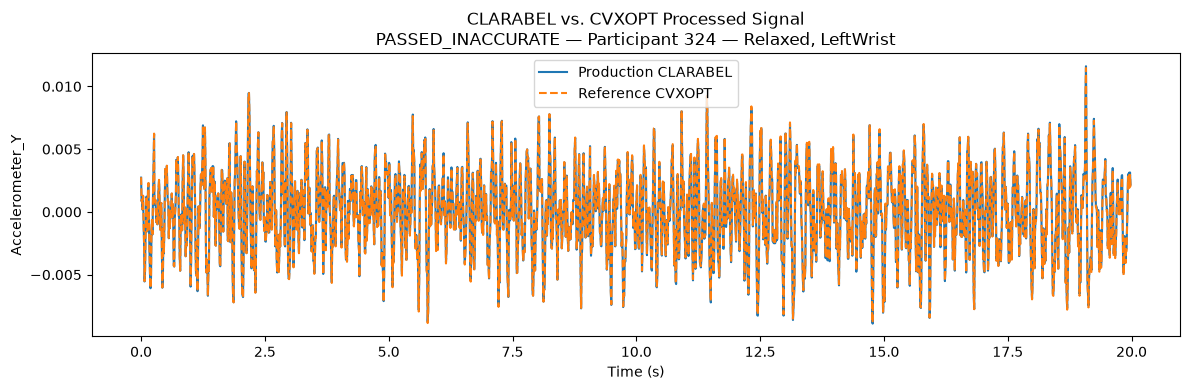

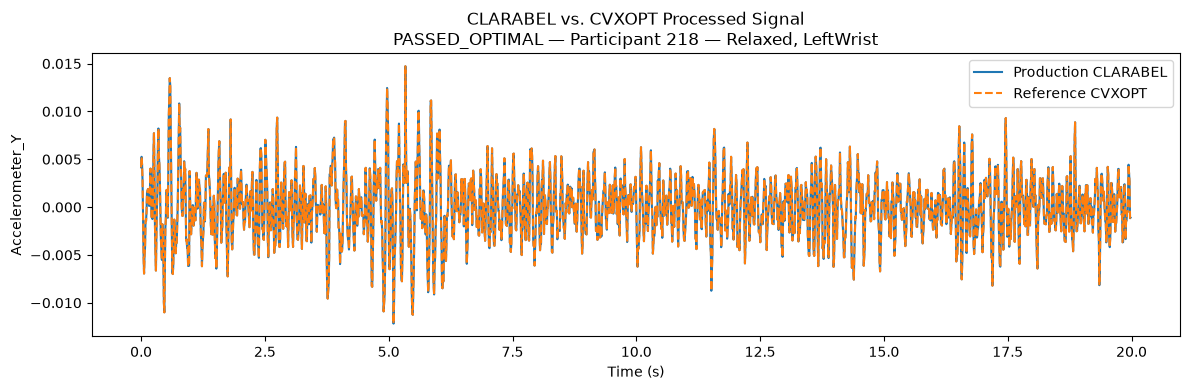

In [51]:
# CLARABEL vs. CVXOPT signal overlays
# =============================================================================

for comparison_key, signal_data in (
    reference_comparison_signals.items()
):

    plt.figure(
        figsize=(12, 4)
    )

    plt.plot(
        signal_data["time"],
        signal_data["clarabel"],
        label="Production CLARABEL",
    )

    plt.plot(
        signal_data["time"],
        signal_data["cvxopt"],
        label="Reference CVXOPT",
        linestyle="--",
    )

    plt.xlabel(
        "Time (s)"
    )

    plt.ylabel(
        REFERENCE_AXIS
    )

    plt.title(
        "CLARABEL vs. CVXOPT Processed Signal\n"
        f"{signal_data['production_status']} — "
        f"Participant {signal_data['patient_id']} — "
        f"{REFERENCE_TASK}, {REFERENCE_WRIST}"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

### Pointwise Solver Difference

The following plots show the pointwise difference:

CLARABEL- CVXOPT

A difference signal centered close to zero with relatively small amplitude indicates close agreement between the two numerical solutions.

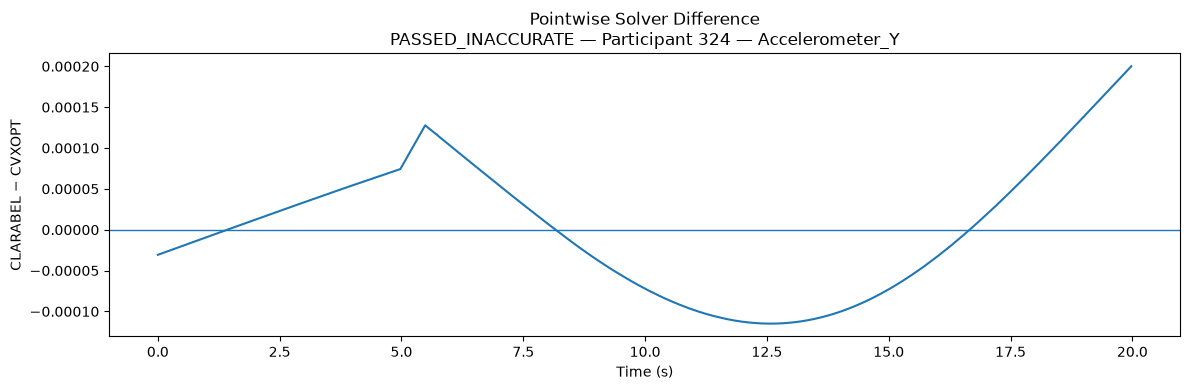

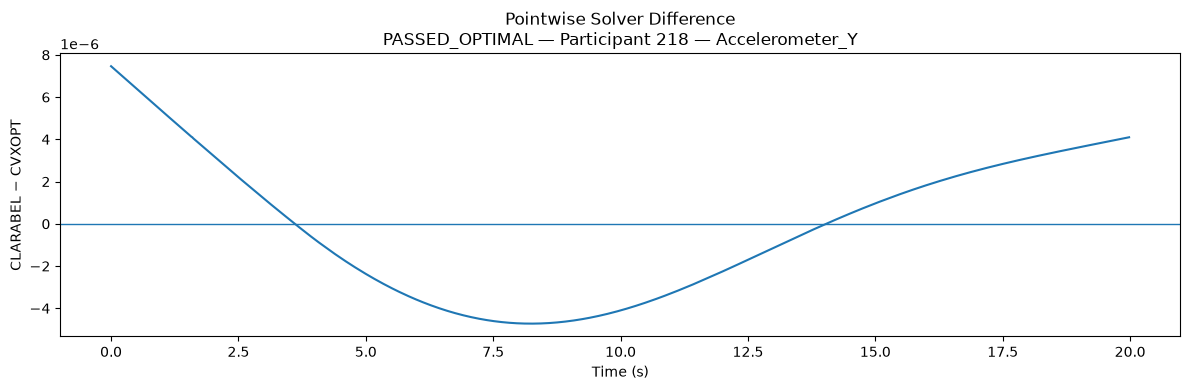

In [52]:
# Pointwise CLARABEL minus CVXOPT differences
# =============================================================================

for comparison_key, signal_data in (
    reference_comparison_signals.items()
):

    plt.figure(
        figsize=(12, 4)
    )

    plt.plot(
        signal_data["time"],
        signal_data["difference"],
    )

    plt.axhline(
        0,
        linewidth=1,
    )

    plt.xlabel(
        "Time (s)"
    )

    plt.ylabel(
        "CLARABEL − CVXOPT"
    )

    plt.title(
        "Pointwise Solver Difference\n"
        f"{signal_data['production_status']} — "
        f"Participant {signal_data['patient_id']} — "
        f"{REFERENCE_AXIS}"
    )

    plt.tight_layout()

    plt.show()

### Interpretation

The reference-solver validation showed close agreement between the production CLARABEL output and the independently generated CVXOPT solution for both selected recordings.

For the `PASSED_OPTIMAL` control recording, the two processed signals were nearly identical:

- Pearson correlation: 0.999999
- RMSE: 0.000003
- Relative RMSE: 0.10%
- Maximum absolute difference: 0.000007

The selected `PASSED_INACCURATE` recording showed greater numerical disagreement than the optimal control, as expected from its reduced-accuracy solver status. However, agreement with the CVXOPT reference remained very high:

- Pearson correlation: 0.999688
- RMSE: 0.000080
- Relative RMSE: 2.50%
- Maximum absolute difference: 0.000200

The CLARABEL and CVXOPT signals showed close visual overlap, and no discontinuities, structural abnormalities, or noticeable distortion of the processed movement signal were observed.

These results indicate that the `optimal_inaccurate` status was associated with a small increase in numerical error, but it did not produce a materially different processed signal in the selected validation case.

Therefore, the `PASSED_INACCURATE` recordings were retained in the processed wearable dataset, while their solver statuses and warnings remained documented in the preprocessing quality report.

This validation is based on a targeted sample and does not establish numerical equivalence for all 1,477 reduced-accuracy recordings. However, together with the dataset-wide structural checks and the absence of preprocessing failures, it provides supporting evidence that retaining these recordings is reasonable for subsequent feature engineering.

In [53]:
# Save reference-solver validation results locally
# =============================================================================

REFERENCE_OUTPUT_DIR = (
    PROCESSED_DIR
    / "solver_validation"
)

REFERENCE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


reference_solver_results.to_csv(
    REFERENCE_OUTPUT_DIR
    / "clarabel_cvxopt_status_validation.csv",
    index=False,
)


print(
    "Results saved to:",
    REFERENCE_OUTPUT_DIR
    / "clarabel_cvxopt_status_validation.csv",
)

Results saved to: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed\solver_validation\clarabel_cvxopt_status_validation.csv


## Conclusion

The complete PADS wearable dataset was successfully preprocessed and validated.

The final pipeline processed **10,318 smartwatch recordings from 469 participants**, preserving all 11 motor tasks and both wrists.

For every recording:

- the accelerometer axes were processed using the same L1 trend-filter formulation (`λ = 50`),
- CLARABEL was used consistently as the numerical solver,
- the initial 48 samples were removed,
- time was re-zeroed,
- gyroscope signals were preserved,
- and accelerometer and gyroscope vector magnitudes were calculated.

A total of **8,841 recordings (85.69%)** achieved fully `OPTIMAL` solver status across all accelerometer axes, while **1,477 recordings (14.31%)** contained at least one `OPTIMAL_INACCURATE` axis. Reduced-accuracy outcomes were retained and explicitly recorded for numerical-quality auditing.

The reduced-accuracy outcomes were strongly task-dependent, particularly for the `Relaxed` and `RelaxedTask` recordings, rather than being randomly distributed throughout the dataset.

Importantly, **no true preprocessing failures occurred**.

All processed recordings were successfully stored in **469 participant-level `.npz` files**, each containing the 22 expected task–wrist recordings.

The processed wearable signals are therefore ready for the feature-engineering stage.

## Next Step

The next stage is wearable feature engineering.

Features will be extracted separately according to:

- motor task,
- wrist,
- sensor type,
- signal axis,
- and signal magnitude.

The planned feature groups include:

### Time-domain features
- mean
- median
- standard deviation
- minimum and maximum
- range
- interquartile range
- root mean square (RMS)
- signal energy

### Frequency-domain features
- dominant frequency
- spectral centroid
- spectral entropy
- spectral power

Subsequent analysis will also evaluate:

- task-specific feature behavior,
- left/right wrist differences,
- accelerometer versus gyroscope features,
- bilateral symmetry and asymmetry,
- feature completeness,
- low-variance and constant features,
- and strongly correlated features.

The resulting wearable feature table will later be aggregated at the participant level and integrated with demographic and questionnaire information.